# Advertising brand capital — a quantitative teardown 🔬
### The advertising-intensity long-short · HAC inference · a label-shuffle placebo · a fraction-robustness sweep · costs + short-borrow · a synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **heavy advertisers earn a forward premium because the market under-prices brand capital** (Belo-Lin-Vitorino 2014; Chan-Lakonishok-Sougiannis 2001) — is an intangible-mispricing claim, distinct from the R&D ([525](../../525-r-and-d-intensity/)), intangible-value ([526](../../526-intangible-value/)) and patent ([400](../../400-patent-intensity/)) siblings. The job: measure the advertising/sales long-short honestly, on a clean point-in-time tape, and see whether it clears the desk's `t >= 2` bar in the predicted direction.

> ⚠️ **Data note.** SEC EDGAR companyconcept (`AdvertisingExpense` / `MarketingAndAdvertisingExpense`, revenue) + yfinance monthly total returns, 2010-02-28 → 2026-06-30. Survivorship named on the Signal axis (current-membership consumer basket). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `979148cad57d`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from advertising_brand import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real(allow_survivorship_bias=True)   # survivorship named on the Signal axis
    SIG = data.build_signal(REAL)
else:
    REAL = SIG = None
print("real cache present:", HAVE_REAL,
      "| basket names:", (0 if REAL is None else REAL["returns"].shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-02-28', 'end': '2026-06-30', 'n_months': 196, 'n_basket': 46, 'n_adv_names': 46, 'adv_fill_pct': 88, 'adv_fy_min': 2008, 'adv_fy_max': 2026, 'n_marketing': 9, 'long_cagr': 12.81, 'long_sh': 0.92, 'long_dd': -28.2, 'long_mean': 13.12, 'short_cagr': 16.17, 'short_sh': 1.11, 'short_dd': -22.3, 'short_mean': 16.13, 'ls_cagr': -3.32, 'ls_sh': -0.35, 'ls_dd': -45.9, 'spy_cagr': 14.56, 'spy_sh': 1.02, 'spy_dd': -23.9, 'spy_mean': 14.71, 'ls_mean': -3.0, 'ls_t': -1.46, 'ls_net_mean': -4.0, 'ls_net_t': -1.94, 'long_spy_mean': -1.47, 'long_spy_t': -0.62, 'short_spy_mean': 1.54, 'short_spy_t': 0.65, 'welch_legs': -0.6, 'hit': 91, 'n_ls': 196, 'hit_pct': 46.4, 'wilson_lo': 39.6, 'wilson_hi': 53.4, 'turnover_pct': 1.04, 'placebo_pctile': 13.3, 'placebo_p': 0.2, 'placebo_null_mean': -0.18, 'placebo_null_sd': 2.34, 'rob': {'half': (-0.68, -0.41), 'tertile': (-3.0, -1.46), 'quartile': (-3.47, -1.33), 'quintile': (-2.24, -0.81)}, 'syn_edge0': (0.47, 0.18), 'syn_edge6': (6.47, 2.47), 'syn_edge8': (8.47, 3.23), 'syn_null20_mean': -0.22, 'syn_null20_sd': 0.43, 'syn_null20_fire': 0, 'top_intens': [('ETSY', 27.4), ('EXPE', 26.5), ('CL', 13.3), ('CHD', 11.4), ('DPZ', 11.3), ('KO', 11.3)], 'bot_intens': [('TGT', 1.41), ('LOW', 1.1), ('TJX', 1.09), ('HD', 0.75), ('WMT', 0.75), ('ROST', 0.33)], 'long_final': ['CHD', 'CL', 'CLX', 'CMCSA', 'DECK', 'DIS', 'DPZ', 'EBAY', 'ETSY', 'EXPE', 'KO', 'NKE', 'PG', 'STZ', 'TAP'], 'short_final': ['BBY', 'CAG', 'CMG', 'F', 'HD', 'LOW', 'ROST', 'SBUX', 'SJM', 'T', 'TGT', 'TJX', 'VZ', 'WMT', 'YUM'], 'cost_bps': 10, 'borrow_bps': 100, 'fp': '979148cad57d'}


real cache present: True | basket names: 46


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | heavy-minus-light advertising long-short **-3.00%/yr**, HAC **t = -1.46** (need +2; the estimate is *negative*), placebo p = 0.20 |
| **Tradability** | `MIRAGE` | wrong-signed & insignificant gross; net of 10bps turnover + 100bps/yr borrow = -4.00%/yr (t = -1.94) |

> 💡 In plain words: the brand-capital premium is *positive* in theory. On this tape the advertising-intensity spread is **negative and inside its own error bar** — no signal, and nothing to trade. The negative sign is the decade's staples-vs-retail style rotation, not an advertising effect (the placebo confirms the ranking loads on no reliable return axis).

## 1 · The claim, steelmanned

Let $A_{i}$ be firm $i$'s advertising expense and $S_i$ its sales in the most-recent reported fiscal year; the intensity signal is $x_{i} = A_i / S_i$. Form the monthly cross-sectional sort, long the top tertile (heavy advertisers), short the bottom. The claims:

- **H₁ (premium).** $E[r^{\text{heavy}} - r^{\text{light}}] > 0$ — advertising intensity earns a positive forward spread (brand capital is under-priced).
- **H₂ (real signal).** The spread clears an autocorrelation-robust `t >= 2` **and** sits in the tail of a label-shuffle placebo.
- **H₃ (tradable).** It survives one-way turnover cost + short-borrow.

We find **H₁ rejected** (spread is *negative*, -3.00%/yr), **H₂ rejected** (HAC t = -1.46, placebo p = 0.20), **H₃ moot** (nothing to trade). The literature's premium does not appear on this tape.

## 2 · So what? — inference design

The long-short is a monthly return series, so the primary Signal-axis test is a **Newey-West HAC** *t* of its mean (H₀: mean = 0), with the desk bar at 2 — and, because the claim is *directional*, **positive** 2. A **label-shuffle placebo** permutes the signal across names (same values, wrong names) and rebuilds the long-short 400× — if the real spread isn't in the tail, the ranking carries no return information. Costs are **one-way × NAV** per rebalance; the short leg pays an annual **borrow**. One execution lag (signal at month *t* → book held *t+1*), one reporting lag (a year on the fundamentals). Survivorship is on the Signal axis.

## 3 · How we'd know — the protocol

- **Panel.** 46 consumer names filing the advertising line; advertising fill ≈ 88% of name-years (FY 2008-2026); 9 names file the broader Marketing&Advertising tag (flagged). 196 holding months, 2010-02-28 → 2026-06-30.
- **Headline.** HAC t of the heavy-minus-light long-short + long-vs-SPY and short-vs-SPY decomposition + a positive-month hit rate with a Wilson interval.
- **Placebo.** 400 label shuffles; percentile + two-sided p of the real spread.
- **Robustness.** Tighten the sort halves → quintiles.
- **Costs.** One-way turnover × NAV + annual short-borrow.
- **Control.** Synthetic panel with a planted advertising premium; the null (edge=0) must not fire across 20 seeds, a planted edge must be recovered.

> **What would flip the verdict to `REAL`:** a *positive* HAC t ≥ 2 that survives the placebo. We announce it before looking.

## 4 · The teardown

### 4a · The race and the HAC test

Long heavy-advertisers, short light-advertisers, equal-weight, monthly. The long and short legs versus SPY, and the HAC *t* of the spread.

leg              CAGR    Sharpe   maxDD    mean/yr
long             12.81%    0.92   -28.2%  +13.12%
short            16.17%    1.11   -22.3%  +16.13%
long_short       -3.32%   -0.35   -45.9%   -3.00%
spy              14.56%    1.02   -23.9%  +14.71%

HAC  long-short -3.00%/yr  t=-1.46
HAC  long - SPY  -1.47%/yr  t=-0.62
HAC  short- SPY  +1.54%/yr  t=+0.65


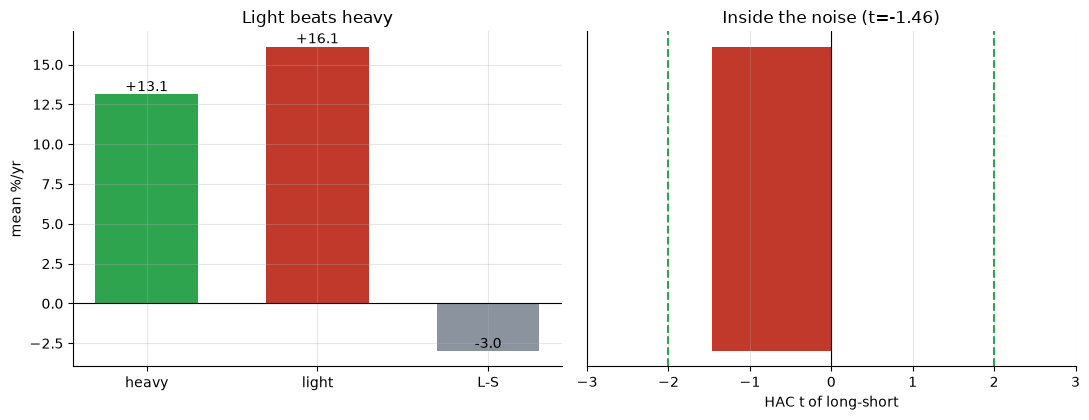

In [2]:
if HAVE_REAL:
    r = st.race(REAL, SIG, frac=1/3, cost_bps=R['cost_bps'], borrow_bps=R['borrow_bps'], n_shuffles=200)
    rows = {k: st.summarize(r[k]) for k in ['long','short','long_short','spy']}
    tls, tl, ts = r['test_ls'], r['test_long_vs_spy'], r['test_short_vs_spy']
    print('leg              CAGR    Sharpe   maxDD    mean/yr')
    for k in ['long','short','long_short','spy']:
        s=rows[k]; print(f"{k:14s} {s['cagr']*100:7.2f}% {s['sharpe']:7.2f} {s['max_dd']*100:7.1f}% {s['mean_ann']*100:+7.2f}%")
    print(f"\nHAC  long-short {tls['mean_ann']*100:+.2f}%/yr  t={tls['tstat']:+.2f}")
    print(f"HAC  long - SPY  {tl['mean_ann']*100:+.2f}%/yr  t={tl['tstat']:+.2f}")
    print(f"HAC  short- SPY  {ts['mean_ann']*100:+.2f}%/yr  t={ts['tstat']:+.2f}")
    ln, sh_, ls_ = rows['long']['mean_ann']*100, rows['short']['mean_ann']*100, tls['mean_ann']*100
    tval = tls['tstat']
else:
    ln, sh_, ls_, tval = R['long_mean'], R['short_mean'], R['ls_mean'], R['ls_t']
fig, (a1,a2) = plt.subplots(1,2,figsize=(11,4.3))
a1.bar(['heavy','light','L-S'], [ln, sh_, ls_], color=[GREEN,RED,GREY], width=.6)
for i,v in enumerate([ln,sh_,ls_]): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('mean %/yr'); a1.set_title('Light beats heavy')
a2.barh([0],[tval],color=RED,height=.5); a2.axvline(2,ls='--',c=GREEN); a2.axvline(-2,ls='--',c=GREEN)
a2.axvline(0,c='k',lw=.8); a2.set_yticks([]); a2.set_xlim(-3,3)
a2.set_xlabel('HAC t of long-short'); a2.set_title(f'Inside the noise (t={tval:+.2f})')
plt.tight_layout(); plt.show()

> 💡 In plain words: the long-short is **-3.00%/yr at HAC t = -1.46** — negative and insignificant. Decomposed: the heavy leg vs SPY is -1.47%/yr (t = -0.62) and the light leg vs SPY is +1.54%/yr (t = +0.65) — neither leg does anything distinguishable from the market. There is simply no advertising premium here.

### 4b · The placebo — does the *signal* carry any return axis?

Permute the advertising-intensity labels across names (same distribution of intensities, attached to the wrong companies) and rebuild the long-short. If the real spread is buried in the middle of that null, the ranking loads on no reliable return axis at all.

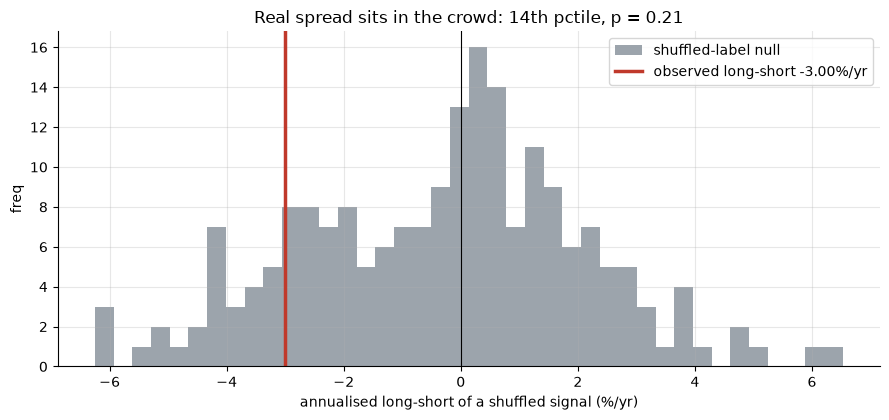

observed -3.00%/yr | null mean -0.33 sd 2.43 | pctile 14 p 0.21


In [3]:
if HAVE_REAL:
    null = r['placebo_null']*100; obs = r['test_ls']['mean_ann']*100
    pctile, pval = r['placebo_pctile'], r['placebo_p']
else:
    rng = np.random.default_rng(791)
    null = rng.normal(R['placebo_null_mean'], R['placebo_null_sd'], 400)
    obs = R['ls_mean']; pctile, pval = R['placebo_pctile'], R['placebo_p']
fig, ax = plt.subplots(figsize=(9,4.3))
ax.hist(null, bins=40, color=GREY, alpha=.85, label='shuffled-label null')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed long-short {obs:+.2f}%/yr')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('annualised long-short of a shuffled signal (%/yr)'); ax.set_ylabel('freq')
ax.set_title(f'Real spread sits in the crowd: {pctile:.0f}th pctile, p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%/yr | null mean {np.mean(null):+.2f} sd {np.std(null):.2f} | pctile {pctile:.0f} p {pval:.2f}')

> 💡 In plain words: a *shuffled* advertising signal pays about the same as the real one — the observed spread sits near the **13th percentile** of the null (two-sided p = 0.20). Unlike study 525's R&D/ME (which at least survived its placebo as a real-but-value axis), advertising intensity here doesn't even clear the placebo: the ranking carries **no** reliable cross-sectional return axis on this basket.

### 4c · Robustness — it isn't hiding at a tighter sort

Tighten the long/short from halves to quintiles; a real signal often sharpens at the extremes. This one just stays negative and insignificant.

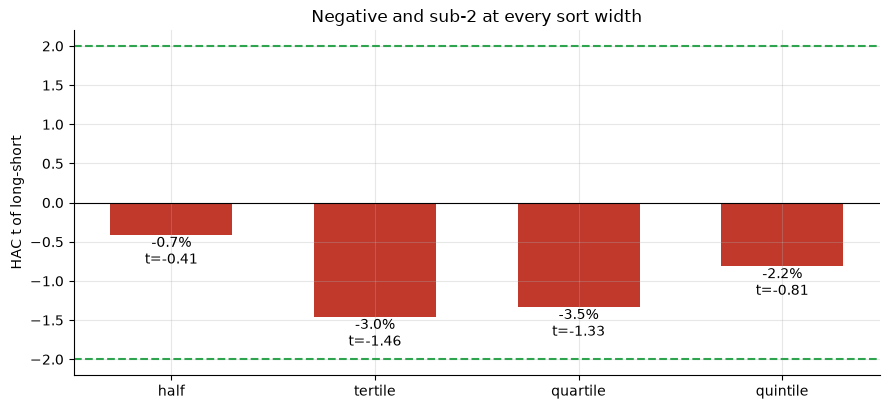

{'half': (-0.7, -0.41), 'tertile': (-3.0, -1.46), 'quartile': (-3.5, -1.33), 'quintile': (-2.2, -0.81)}


In [4]:
splits = ['half','tertile','quartile','quintile']; fracs=[1/2,1/3,1/4,1/5]
if HAVE_REAL:
    ms, tsv = [], []
    for fr in fracs:
        b = st.signal_books(SIG, REAL['returns'], frac=fr); d = st.hac_tstat(b['long_short'])
        ms.append(d['mean_ann']*100); tsv.append(d['tstat'])
else:
    ms = [R['rob'][s][0] for s in splits]; tsv = [R['rob'][s][1] for s in splits]
fig, ax = plt.subplots(figsize=(9,4.2))
ax.bar(splits, tsv, color=[RED if abs(t)<2 else GREEN for t in tsv], width=.6)
ax.axhline(2,ls='--',c=GREEN); ax.axhline(-2,ls='--',c=GREEN); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('HAC t of long-short'); ax.set_title('Negative and sub-2 at every sort width')
for i,(m,t) in enumerate(zip(ms,tsv)): ax.annotate(f'{m:+.1f}%\nt={t:+.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
plt.tight_layout(); plt.show()
print({s: (round(m,1), round(t,2)) for s,m,t in zip(splits,ms,tsv)})

> 💡 In plain words: no sort width rescues it. The spread is negative and inside the noise from halves to quintiles — there is no concentrated tail where a hidden premium lives.

### 4d · Costs + short-borrow — the moot cost check

Advertising intensity is a *slow* annual characteristic, so turnover is tiny; the only material friction is short-borrow. It makes a negative spread more negative — but the point is academic, since there is no positive edge to erode in the first place.

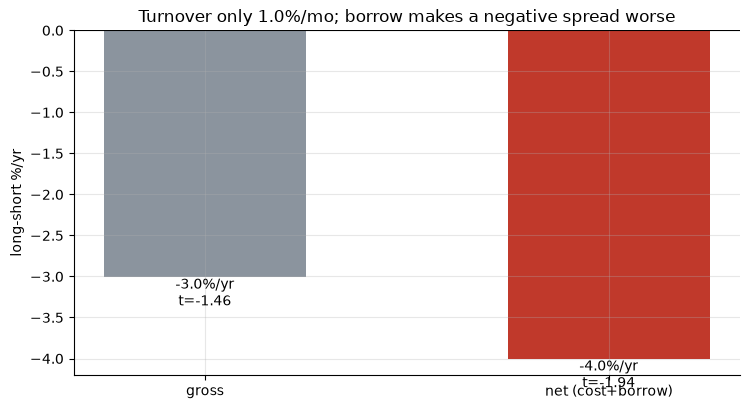

gross -3.00%/yr (t=-1.46) -> net -4.00%/yr (t=-1.94); turnover 1.04%/mo


In [5]:
if HAVE_REAL:
    g = r['test_ls']; nt = r['test_ls_net']; turn = r['avg_turnover']*100
    gm, gt, nm, ntt = g['mean_ann']*100, g['tstat'], nt['mean_ann']*100, nt['tstat']
else:
    gm, gt, nm, ntt, turn = R['ls_mean'], R['ls_t'], R['ls_net_mean'], R['ls_net_t'], R['turnover_pct']
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.bar(['gross','net (cost+borrow)'], [gm, nm], color=[GREY, RED], width=.5)
for i,(v,t) in enumerate([(gm,gt),(nm,ntt)]): ax.annotate(f'{v:+.1f}%/yr\nt={t:+.2f}',(i,v),ha='center',va='top')
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('long-short %/yr')
ax.set_title(f'Turnover only {turn:.1f}%/mo; borrow makes a negative spread worse')
plt.tight_layout(); plt.show()
print(f'gross {gm:+.2f}%/yr (t={gt:+.2f}) -> net {nm:+.2f}%/yr (t={ntt:+.2f}); turnover {turn:.2f}%/mo')

> 💡 In plain words: one-way turnover is only ~1.0%/month (the signal moves once a year), so cost barely matters; short-borrow at 100bps/yr drags the gross -3.00%/yr to -4.00%/yr — but you would never put on a wrong-signed, insignificant book to begin with. **Tradability = MIRAGE.**

### 4e · Faithful-engine & power control — we know the truth here

A deterministic monthly panel (fixed seed, 15 years × 40 names) where the first half are persistently heavy advertisers, market beta is common to both legs, and a knob `edge` plants the *true* annual heavy-minus-light premium. The null (edge=0) is checked over **20 seeds**.

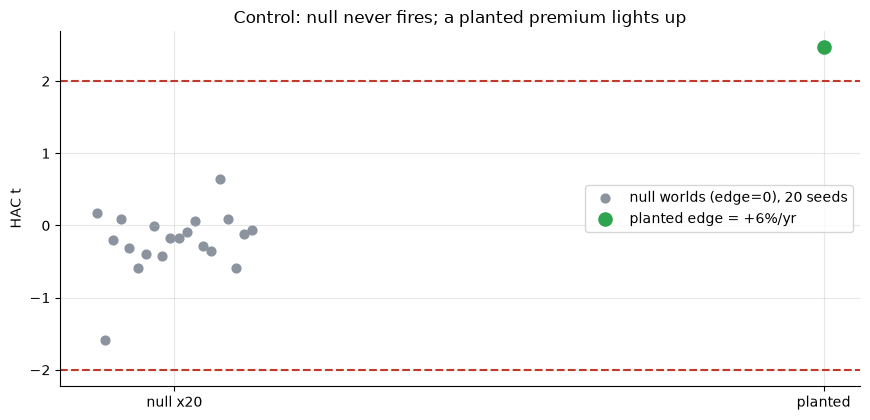

null: mean t=-0.22 (sd 0.43), |t|>=2 in 0/20 | planted t=+2.47


In [6]:
null_ts = []
for s_ in range(20):
    sg, rr, _, _ = data.synthetic_panel(edge=0.0, seed=791 + s_)
    b = st.signal_books(sg, rr, frac=1/3); null_ts.append(st.hac_tstat(b['long_short'])['tstat'])
null_ts = np.asarray(null_ts)
sg, rr, _, _ = data.synthetic_panel(edge=0.06, seed=791)
planted_t = st.hac_tstat(st.signal_books(sg, rr, frac=1/3)['long_short'])['tstat']
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
ax.scatter([1],[planted_t], color=GREEN, s=90, zorder=5, label='planted edge = +6%/yr')
ax.axhline(2,ls='--',c=RED); ax.axhline(-2,ls='--',c=RED)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x20','planted']); ax.set_ylabel('HAC t')
ax.set_title('Control: null never fires; a planted premium lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), |t|>=2 in {(abs(null_ts)>=2).sum()}/20 | planted t={planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.22 and **never** fires (0/20); a planted +6%/yr premium reads t = +2.47. The machinery finds a premium exactly when one exists — so the real-tape null result (-1.46) is a true negative, not a broken pipeline. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — heavy-minus-light advertising long-short **-3.00%/yr**, HAC **t = -1.46** (the claim needs *positive* t ≥ 2; the estimate is negative). The placebo doesn't clear it either (13th pctile, p = 0.20), and no sort width (halves → quintiles) rescues it. Neither leg beats SPY. No brand premium on this tape.
- **Tradability `MIRAGE`** — a wrong-signed, insignificant spread; net of 10bps turnover + 100bps/yr borrow it is -4.00%/yr (t = -1.94). Nothing to allocate to.

The literature (Belo-Lin-Vitorino; Chan-Lakonishok-Sougiannis) reports a brand/intangible premium; **this clean, point-in-time, disclosure-limited tape cannot certify it** — and over 2010-2026 the raw sign is backwards, driven by the staples-vs-retail style rotation rather than anything about advertising.

## 6 · Going further

- **Denominator.** Chan-Lakonishok-Sougiannis find intangible mispricing concentrates when scaling by **market value**, not sales; an advertising/market-cap signal (the brand-capital analogue of study 525's R&D/ME) is the obvious next test.
- **Brand-capital stock.** Belo-Lin-Vitorino accumulate advertising into a perpetual-inventory *stock* rather than using the raw annual flow; that smoother measure could carry signal the flow ratio doesn't.
- **Coverage.** Post-2015 disclosure is thin and self-selected; a serious test needs a wider historical universe (pre-2015, when the line was more commonly filed) or a vendor brand-value dataset — both beyond a public-EDGAR basket.
- **Dedup map:** [525-r-and-d-intensity](../../525-r-and-d-intensity/) (R&D, and the ME-vs-sales denominator contrast), [526-intangible-value](../../526-intangible-value/) (intangible-adjusted book-to-market), [400-patent-intensity](../../400-patent-intensity/) (patents). Same family; this is the **advertising** axis specifically.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*